<a href="https://colab.research.google.com/github/HudaSaffo/fashion-recommendation-system/blob/week4-embeddings-retrieval/embeddings_and_retrieval.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week 4 — Multimodal Item Embeddings and Retrieval

## Objective

Create a searchable fashion-product system that can find relevant items from a user’s text query.

## Inputs

- Refined product catalog from Week 2
- Transparent product cutouts from Week 3
- Refined visual category and color labels

## Method

Each product is represented using three CLIP embeddings:

1. **Text embedding** — created from the title, description, category, colour, material, season, style, occasion, fit, formality, and price.
2. **Image embedding** — created from the transparent product cutout.
3. **Combined embedding** — a weighted combination of text and image embeddings:
   - Text weight: 60%
   - Image weight: 40%

The combined embeddings are stored in a FAISS index for fast similarity search.

## Output

When a user enters a query such as *“minimal white sneakers for summer”*, the system returns the most relevant products with their image, title, category, colour, price, and similarity score.

## 1. Install Required Libraries

Install OpenCLIP for generating embeddings, FAISS for similarity search, and supporting libraries for images and Parquet files.

In [1]:
%pip install -q open_clip_torch faiss-cpu pyarrow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 23.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.8/18.8 MB 109.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 4.4 MB/s eta 0:00:00


## 2. Import Libraries and Configure Paths

Import the required libraries and define the locations of the refined catalog, Week 3 segmentation manifest, and Week 4 output folder.

In [12]:
from pathlib import Path
import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
import torch
import faiss
import open_clip

CATALOG_PATH = '/content/drive/MyDrive/catalog_refined.parquet'
SEGMENTATION_MANIFEST_PATH = (
    '/content/drive/MyDrive/polyvore_segmented_cache/segmentation_manifest.csv'
)
OUTPUT_DIR = Path('/content/drive/MyDrive/fashion_embeddings')

MAX_ITEMS = None
OVERWRITE = False
BATCH_SIZE = 32
MODEL_NAME = 'ViT-B-32'
PRETRAINED = 'laion2b_s34b_b79k'
TEXT_WEIGHT = 0.6
IMAGE_WEIGHT = 0.4
NEUTRAL_RGB = (245, 245, 245)
DEVICE = 'cuda'

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print('GPU:', torch.cuda.get_device_name(0))
print('Output directory:', OUTPUT_DIR)

GPU: Tesla T4
Output directory: /content/drive/MyDrive/fashion_embeddings


## 3. Load and Join Product Data

Load the refined catalog and successful Week 3 cutouts. Join them using `item_id` so every searchable product has both metadata and an image.

In [13]:
catalog = pd.read_parquet(CATALOG_PATH)
manifest = pd.read_csv(SEGMENTATION_MANIFEST_PATH)

assert 'item_id' in catalog.columns, 'Catalog is missing item_id'
assert 'item_id' in manifest.columns, 'Manifest is missing item_id'
assert 'cutout_path' in manifest.columns, 'Manifest is missing cutout_path'

catalog['item_id'] = catalog['item_id'].astype(str).str.strip()
manifest['item_id'] = manifest['item_id'].astype(str).str.strip()

catalog = catalog.drop_duplicates('item_id')
manifest = manifest.drop_duplicates('item_id')

joined = catalog.merge(
    manifest,
    on='item_id',
    how='inner',
    validate='one_to_one'
)

print('Items ready for embeddings:', len(joined))

Items ready for embeddings: 3673


## 4. Build Searchable Product Text

Combine each product’s title, description, refined category, refined colour, and other available metadata into one text description for text embedding.

In [14]:
def build_item_text(row):
    return (
        f"Title: {row['title']}. "
        f"Description: {row['description']}. "
        f"Category: {row['refined_category']}. "
        f"Color: {row['refined_color']}. "
        f"Material: {row['material']}. "
        f"Season: {row['season']}. "
        f"Style: {row['style']}. "
        f"Occasion: {row['occasion']}. "
        f"Fit: {row['fit']}. "
        f"Formality: {row['formality']}. "
        f"Price: {row['real_price']}. "
        f"Price range: {row['price_bucket']}."
    )

joined['item_text'] = joined.apply(build_item_text, axis=1)

print('Items ready for text embedding:', len(joined))
display(joined[['item_id', 'item_text']].head(3))

Items ready for text embedding: 3673


,item_id,item_text
0,154249722,"Title: L.L.Bean Scotch Plaid Shirt, Relaxed. D..."
1,188425631,Title: A stylish pair of accessories: Pre-owne...
2,183214727,Title: Max Mara Slim Leg Trousers. Description...


## 5. Select Products for Embedding

Keep products with valid text information and transparent PNG cutouts. Use a small sample for testing or all products for the final run.

In [15]:
valid_df = joined.copy()

if MAX_ITEMS is not None:
    valid_df = valid_df.head(int(MAX_ITEMS)).copy()

if valid_df.empty:
    raise RuntimeError('No items are available for embedding.')

print(f'Embedding {len(valid_df)} items (MAX_ITEMS={MAX_ITEMS}).')

Embedding 3673 items (MAX_ITEMS=None).


## 6. Generate Text, Image, and Combined Embeddings

Use CLIP to convert product text and cutout images into numerical vectors. Create the combined embedding using 60% text information and 40% image information.

In [16]:
DEVICE = 'cuda'

model, _, preprocess = open_clip.create_model_and_transforms(
    MODEL_NAME,
    pretrained=PRETRAINED
)
tokenizer = open_clip.get_tokenizer(MODEL_NAME)
model = model.to(DEVICE).eval()

def l2_normalize(array, eps=1e-12):
    array = np.asarray(array, dtype=np.float32)
    norms = np.linalg.norm(array, axis=1, keepdims=True)
    return array / np.clip(norms, eps, None)

def composite_cutout(path, background=NEUTRAL_RGB):
    with Image.open(path) as source:
        rgba = source.convert('RGBA')
    canvas = Image.new('RGBA', rgba.size, (*background, 255))
    return Image.alpha_composite(canvas, rgba).convert('RGB')

ARTIFACTS = {
    'text': OUTPUT_DIR / 'text_embeddings.npy',
    'image': OUTPUT_DIR / 'image_embeddings.npy',
    'combined': OUTPUT_DIR / 'combined_embeddings.npy',
    'catalog': OUTPUT_DIR / 'retrieval_catalog.parquet',
}

all_artifacts_exist = all(
    ARTIFACTS[key].exists()
    for key in ARTIFACTS
)

if all_artifacts_exist and not OVERWRITE:
    retrieval_catalog = pd.read_parquet(ARTIFACTS['catalog'])
    text_embeddings = np.load(ARTIFACTS['text'])
    image_embeddings = np.load(ARTIFACTS['image'])
    combined_embeddings = np.load(ARTIFACTS['combined'])
    expected_ids = valid_df['item_id'].astype(str).tolist()
    saved_ids = retrieval_catalog['item_id'].astype(str).tolist()
    shapes_ok = all(
        embedding.shape[0] == len(saved_ids)
        for embedding in [
            text_embeddings,
            image_embeddings,
            combined_embeddings,
        ]
    )
    if not shapes_ok or saved_ids != expected_ids:
        raise RuntimeError(
            'Existing embeddings do not match this run. '
            'Set OVERWRITE=True to create them again.'
        )
    print('Loaded saved embeddings; generation skipped.')

else:
    if any(ARTIFACTS[key].exists() for key in ARTIFACTS) and not OVERWRITE:
        raise RuntimeError(
            'Partial embedding outputs exist. '
            'Set OVERWRITE=True to rebuild them.'
        )
    text_chunks = []
    image_chunks = []
    for start in tqdm(
        range(0, len(valid_df), BATCH_SIZE),
        desc='Embedding batches'
    ):
        batch = valid_df.iloc[start:start + BATCH_SIZE]
        texts = batch['item_text'].tolist()
        images = [
            preprocess(composite_cutout(path))
            for path in batch['cutout_path']
        ]
        tokens = tokenizer(texts).to(DEVICE)
        pixels = torch.stack(images).to(DEVICE)
        with torch.inference_mode():
            with torch.autocast(device_type='cuda', dtype=torch.float16):
                text_features = model.encode_text(tokens)
                image_features = model.encode_image(pixels)
        text_chunks.append(text_features.float().cpu().numpy())
        image_chunks.append(image_features.float().cpu().numpy())
    retrieval_catalog = valid_df.copy().reset_index(drop=True)
    text_embeddings = l2_normalize(
        np.concatenate(text_chunks, axis=0)
    )
    image_embeddings = l2_normalize(
        np.concatenate(image_chunks, axis=0)
    )
    combined_embeddings = l2_normalize(
        TEXT_WEIGHT * text_embeddings +
        IMAGE_WEIGHT * image_embeddings
    )
    assert (
        len(retrieval_catalog)
        == len(text_embeddings)
        == len(image_embeddings)
        == len(combined_embeddings)
    )
    np.save(ARTIFACTS['text'], text_embeddings)
    np.save(ARTIFACTS['image'], image_embeddings)
    np.save(ARTIFACTS['combined'], combined_embeddings)
    retrieval_catalog.to_parquet(ARTIFACTS['catalog'], index=False)
    print('Saved embedding files.')

print('Embedding shapes:')
print('Text:', text_embeddings.shape)
print('Image:', image_embeddings.shape)
print('Combined:', combined_embeddings.shape)

Embedding batches:   0%|          | 0/115 [00:00<?, ?it/s]

Saved embedding files.
Embedding shapes:
Text: (3673, 512)
Image: (3673, 512)
Combined: (3673, 512)


## 7. Create the FAISS Similarity Index

Store the combined embeddings in a FAISS index so similar products can be retrieved quickly from a text query.

In [17]:
INDEX_PATH = OUTPUT_DIR / 'combined.index'

if INDEX_PATH.exists() and not OVERWRITE:
    index = faiss.read_index(str(INDEX_PATH))
    if (
        index.ntotal != len(combined_embeddings)
        or index.d != combined_embeddings.shape[1]
    ):
        raise RuntimeError(
            'Existing index does not match the combined embeddings. '
            'Set OVERWRITE=True to rebuild it.'
        )
    print(f'Loaded combined index: {INDEX_PATH}')

else:
    vectors = np.ascontiguousarray(
        combined_embeddings,
        dtype=np.float32
    )
    index = faiss.IndexFlatIP(vectors.shape[1])
    index.add(vectors)
    faiss.write_index(index, str(INDEX_PATH))
    print(f'Saved combined index: {INDEX_PATH}')

Saved combined index: /content/drive/MyDrive/fashion_embeddings/combined.index


## 8. Search From a User Query

Convert the user’s query into an embedding and retrieve the top matching fashion items from the FAISS index.

In [18]:
def encode_text_query(query):
    if not isinstance(query, str) or not query.strip():
        raise ValueError('Query must be a non-empty string.')
    with torch.inference_mode():
        features = model.encode_text(
            tokenizer([query.strip()]).to(DEVICE)
        )
    return l2_normalize(
        features.float().cpu().numpy()
    )

def search_items(query, top_k=8):
    if index.ntotal == 0:
        raise RuntimeError('The FAISS index is empty.')
    k = min(max(int(top_k), 1), index.ntotal)
    query_embedding = np.ascontiguousarray(
        encode_text_query(query),
        dtype=np.float32
    )
    scores, positions = index.search(query_embedding, k)
    results = []
    for score, position in zip(scores[0], positions[0]):
        row = retrieval_catalog.iloc[int(position)]
        results.append({
            'item_id': str(row['item_id']),
            'title': row['title'],
            'description': row['description'],
            'category': row['refined_category'],
            'color': row['refined_color'],
            'style': row['style'],
            'season': row['season'],
            'estimated_price': row['real_price'],
            'price_bucket': row['price_bucket'],
            'similarity_score': float(score),
            'cutout_path': str(row['cutout_path']),
        })
    return pd.DataFrame(results)

QUERY = 'minimal white sneakers for summer'
TOP_K = 8

results = search_items(QUERY, TOP_K)
display(results)

,item_id,title,description,category,color,style,season,estimated_price,price_bucket,similarity_score,cutout_path
0,134527579,A stylish pair of shoes: Shoes Boots Sandals H...,A stylish pair of shoes: Shoes Boots Sandals H...,shoes,white,streetwear,summer,48.08,mid-tier,0.709183,/content/drive/MyDrive/polyvore_segmented_cach...
1,180054828,A stylish pair of shoes: White Round Toe Lace-...,A stylish pair of shoes: White Round Toe Lace-...,shoes,white,classic,all-season,54.54,mid-tier,0.708190,/content/drive/MyDrive/polyvore_segmented_cach...
2,191156564,A stylish pair of shoes: White Lace Up Pu Rubber,A stylish pair of shoes: White Lace Up Pu Rubber,shoes,white,minimalist,all-season,63.86,mid-tier,0.706675,/content/drive/MyDrive/polyvore_segmented_cach...
3,208963754,A stylish pair of shoes: White Hidden Wedge Pu...,A stylish pair of shoes: White Hidden Wedge Pu...,shoes,white,classic,all-season,42.26,mid-tier,0.683213,/content/drive/MyDrive/polyvore_segmented_cach...
4,179235709,Round Toe Lace-up Star Sneakers,Round Toe Lace-up Star Sneakers,shoes,white,classic,all-season,46.42,mid-tier,0.664847,/content/drive/MyDrive/polyvore_segmented_cach...
5,183346612,A stylish pair of shoes: Flirting,A stylish pair of shoes: Flirting,shoes,white,classic,all-season,72.62,mid-tier,0.652474,/content/drive/MyDrive/polyvore_segmented_cach...
6,144696530,A stylish pair of shoes: Swear Diana Loafers,A stylish pair of shoes: Swear Diana Loafers,shoes,white,classic,all-season,58.66,mid-tier,0.652127,/content/drive/MyDrive/polyvore_segmented_cach...
7,136930118,A stylish pair of shoes: Amazon.com Ash Womens...,A stylish pair of shoes: Amazon.com Ash Womens...,shoes,white,streetwear,all-season,63.35,mid-tier,0.628455,/content/drive/MyDrive/polyvore_segmented_cach...


## 9. Visual Retrieval Debug Interface

Display the retrieved product cutouts with their metadata and similarity scores to evaluate whether the search results match the query.

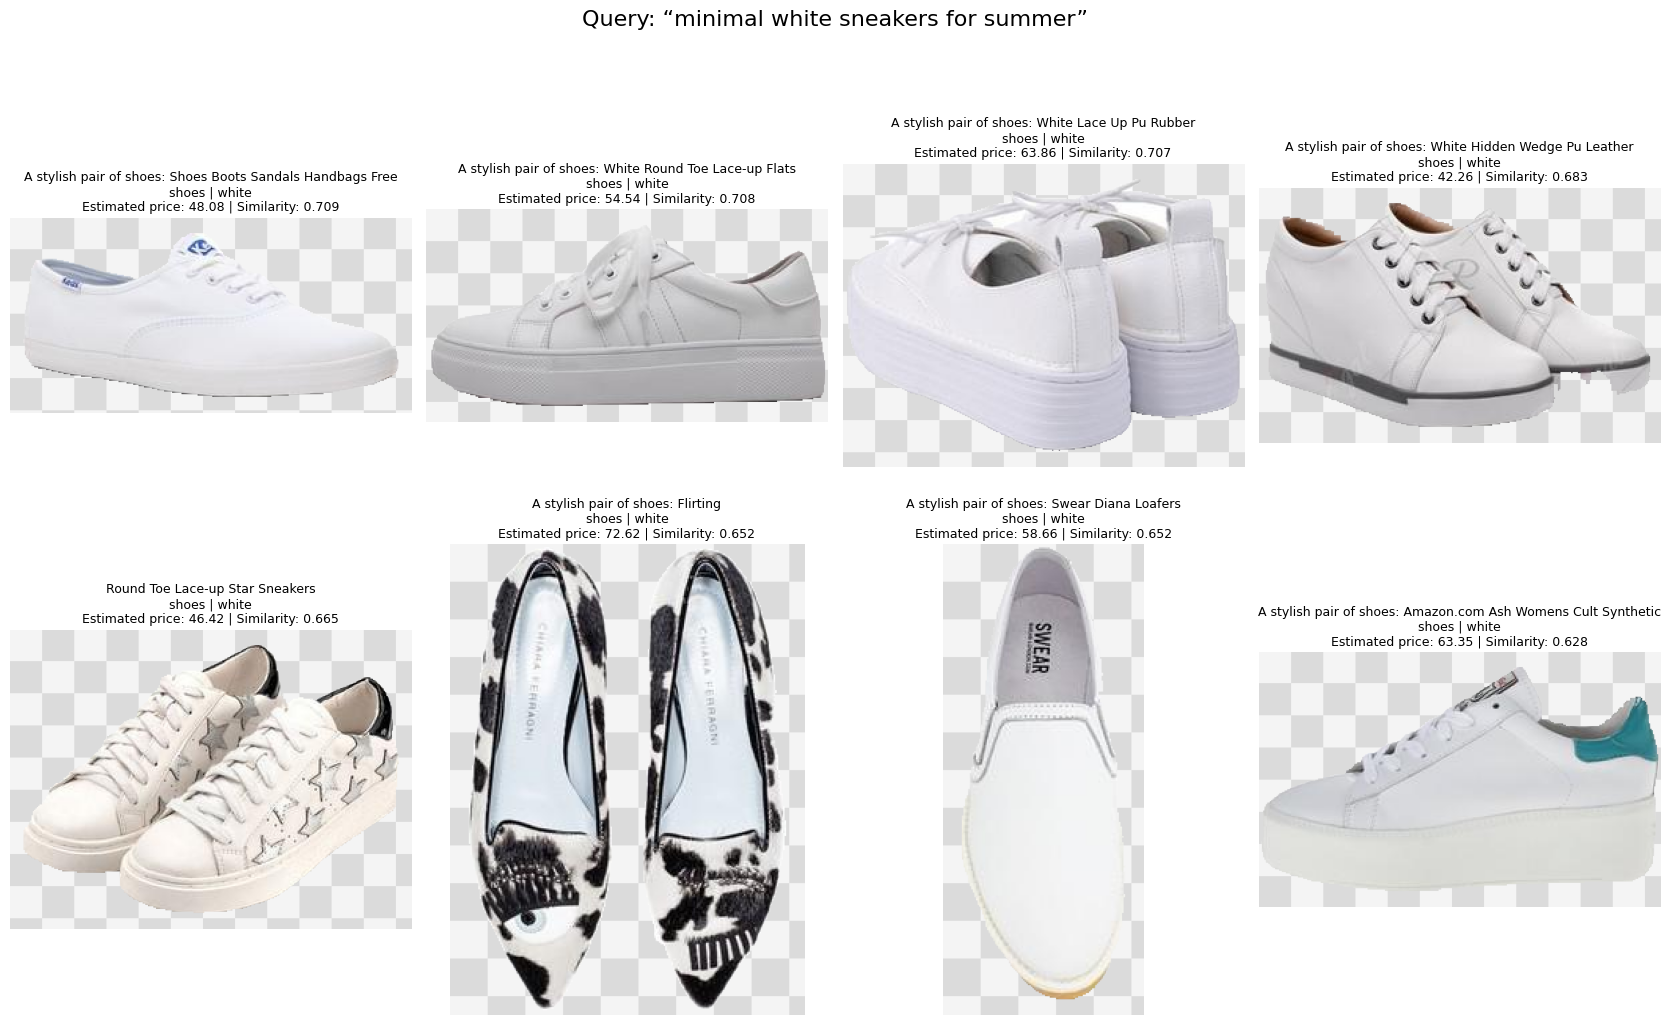

In [19]:
def display_cutout(ax, path):
    with Image.open(path) as source:
        rgba = source.convert('RGBA')
    tile = 24
    yy, xx = np.indices((rgba.height, rgba.width))
    checker = (xx // tile + yy // tile) % 2
    background = np.where(checker[..., None] == 0, 0.96, 0.86)
    background = np.repeat(background, 3, axis=2)
    ax.imshow(background)
    ax.imshow(rgba)

def retrieval_debug_ui(query, top_k=5, columns=4):
    found = search_items(query, top_k=top_k)
    if found.empty:
        print('No results.')
        return found
    rows = int(np.ceil(len(found) / columns))
    fig, axes = plt.subplots(
        rows,
        columns,
        figsize=(4.2 * columns, 5.0 * rows),
        squeeze=False
    )
    fig.suptitle(f'Query: “{query}”', fontsize=16, y=1.02)
    for ax, (_, item) in zip(axes.flat, found.iterrows()):
        ax.axis('off')
        display_cutout(ax, item['cutout_path'])
        ax.set_title(
            f"{item['title']}\n"
            f"{item['category']} | {item['color']}\n"
            f"Estimated price: {item['estimated_price']:,.2f} | "
            f"Similarity: {item['similarity_score']:.3f}",
            fontsize=9,
            wrap=True
        )
    for ax in axes.flat[len(found):]:
        ax.axis('off')
    plt.tight_layout()
    plt.show()
    return found

debug_results = retrieval_debug_ui(QUERY, top_k=TOP_K)

## 10. Test Example Queries

Run several fashion-related queries to evaluate retrieval quality across different categories, colours, and styles.

In [20]:
EXAMPLE_QUERIES = [
    'minimal white sneakers for summer',
    'formal black outfit for an evening event',
    'casual blue denim for everyday wear',
]

for example_query in EXAMPLE_QUERIES:
    print('\nQUERY:', example_query)
    display(search_items(example_query, top_k=5)[
            ['item_id', 'title', 'category', 'color', 'estimated_price', 'similarity_score',]
        ])


QUERY: minimal white sneakers for summer


,item_id,title,category,color,estimated_price,similarity_score
0,134527579,A stylish pair of shoes: Shoes Boots Sandals H...,shoes,white,48.08,0.709183
1,180054828,A stylish pair of shoes: White Round Toe Lace-...,shoes,white,54.54,0.708190
2,191156564,A stylish pair of shoes: White Lace Up Pu Rubber,shoes,white,63.86,0.706675
3,208963754,A stylish pair of shoes: White Hidden Wedge Pu...,shoes,white,42.26,0.683213
4,179235709,Round Toe Lace-up Star Sneakers,shoes,white,46.42,0.664847



QUERY: formal black outfit for an evening event


,item_id,title,category,color,estimated_price,similarity_score
0,51638060,A stylish pair of bottoms: Project Black Wrap ...,dresses,black,62.16,0.663272
1,182380784,A stylish pair of accessories: Stylish Neck Lo...,dresses,black,22.44,0.632421
2,206884046,A stylish pair of accessories: Clothing Women ...,bottoms,black,33.29,0.624146
3,151667620,A stylish pair of accessories: Rental Elizabet...,shoes,black,10.77,0.622684
4,192209907,A stylish pair of accessories: Black Spaghetti...,bottoms,black,32.39,0.620453



QUERY: casual blue denim for everyday wear


,item_id,title,category,color,estimated_price,similarity_score
0,181678726,Blue Flip Flop Jeans,bottoms,blue,34.56,0.728888
1,137462342,A stylish pair of bottoms: Cycle Jeans,bottoms,blue,49.03,0.723229
2,122676995,A stylish pair of bottoms: Seven7 Jeans Sateen...,bottoms,blue,25.22,0.677676
3,129100362,A stylish pair of bottoms: Seafarer Lord Jim C...,bottoms,blue,32.47,0.665737
4,179724553,Tomboy Jeans,bottoms,grey,55.69,0.659242


## 11. Verify Saved Week 4 Outputs

Confirm that the embeddings, retrieval catalog, and FAISS index were saved successfully in Google Drive.

In [21]:
required_outputs = [
    'text_embeddings.npy',
    'image_embeddings.npy',
    'combined_embeddings.npy',
    'retrieval_catalog.parquet',
    'combined.index',
]
check = pd.DataFrame({
    'artifact': required_outputs,
    'exists': [(OUTPUT_DIR / name).exists() for name in required_outputs],
    'path': [str(OUTPUT_DIR / name) for name in required_outputs],
})
display(check)

,artifact,exists,path
0,text_embeddings.npy,True,/content/drive/MyDrive/fashion_embeddings/text...
1,image_embeddings.npy,True,/content/drive/MyDrive/fashion_embeddings/imag...
2,combined_embeddings.npy,True,/content/drive/MyDrive/fashion_embeddings/comb...
3,retrieval_catalog.parquet,True,/content/drive/MyDrive/fashion_embeddings/retr...
4,combined.index,True,/content/drive/MyDrive/fashion_embeddings/comb...
